# HCDE 530 — Hardcover books + pandas (`A5_pandas_books.ipynb`)


**Data source:** [Hardcover GraphQL](https://api.hardcover.app/v1/graphql) 

---

**Before you run**

- Open this notebook from **`hcde530_week5`** so the working folder matches the demos (**Shift+Enter** to run cells).
- Put your token in **`hcde530_week5/.env`** as `HARDCOVER_JWT=...` (no `Bearer` prefix in the value; the code adds `Bearer`).
- Install deps for **this notebook kernel**: **`pip install python-dotenv pandas matplotlib`** — or **`pip install -r requirements.txt`** in `hcde530_week5`. The first code cell tries to **`pip install python-dotenv`** automatically if it is missing (needs network once).

---

**pandas.** The coursework asks you to demonstrate *three out of five* common patterns; below we use **four** (enough overlap for the research questions).

| Pattern | Question it answers | This notebook |
|---------|---------------------|----------------|
| `df.head()`, `df.info()` | What does the table look like? | **§1** (same section demonstrates both) |
| `df['col'].value_counts()` | Most common categorical values | **§2** (`genre_slugs` → split/explode → `value_counts`) |
| `df[df['col'] > value]` | Filter to a meaningful subset | **§3** |

---

**Research questions answered below**

1. Which **genre** has books with the **most 1★ + 2★** ratings overall *(see caveats)*?
2. Which books show the **widest** empirical rating spread *(vs books where ≥65% of ratings are **only** whole 1★ or 5★)*?
3. **Correlation:** number of distinct tag slugs vs **average rating**?


---


## Setup — imports and environment

Same idea as **`week5_pandas_demo`**: verify **pandas**, load secrets from **`.env`**, confirm you can reach the GraphQL endpoint.


In [29]:
import json
import math
import os
import ssl
import urllib.request
from pathlib import Path

import importlib.util
import subprocess
import sys

import pandas as pd

if importlib.util.find_spec("dotenv") is None:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", "python-dotenv"]
    )

from dotenv import load_dotenv

pd.set_option("display.max_colwidth", 80)
warnings_mod = __import__("warnings")
warnings_mod.filterwarnings("ignore")

ENV_PATH = Path.cwd() / ".env"
load_dotenv(ENV_PATH)
TOKEN = os.environ.get("HARDCOVER_JWT")
if not TOKEN:
    raise SystemExit(f"Missing HARDCOVER_JWT in {ENV_PATH}")

# SSL fallback for some macOS Python installs
SSL_CTX = ssl.create_default_context()
try:
    SSL_CTX.load_verify_locations(cafile="/etc/ssl/cert.pem")
except OSError:
    SSL_CTX = ssl.create_default_context()

print("pandas:", pd.__version__)
print("token loaded:", bool(TOKEN))


pandas: 3.0.2
token loaded: True


---
## Step A — Pull data from Hardcover and build `df`

We POST a GraphQL query with **`Authorization: Bearer <HARDCOVER_JWT>`**, page through **`books`**, and normalize **`ratings_distribution`** (list of `{rating, count}` half-star buckets) into numeric columns.

**Taggings:** we request **`tag` + `tag_category`**, then split into **`tag_slugs`** (all tags, for RQ3) and **`genre_slugs`** (tags whose category is genre, for RQ1).

**Filters in the query:** `ratings_count >= 40` and active status so distributions are not too sparse for spread metrics.

Run the next cell; it may take **10–30 seconds** depending on network and page size.
---


In [67]:
import json
import urllib.request

GRAPHQL_URL = "https://api.hardcover.app/v1/graphql"
LIMIT_PER_PAGE = 120  # tweak if responses are slow; API may throttle
MAX_PAGES = 3  # pages * limit ~= rows before dedupe edge cases


def fetch_books_page(limit: int, offset: int) -> list:
    """Run one GraphQL request; returns `books` list or raises."""
    query = """
    query Books($limit: Int!, $offset: Int!) {
      books(
        where: {
          ratings_count: { _gte: 40 }
          book_status_id: { _eq: 1 }
        }
        order_by: { ratings_count: desc }
        limit: $limit
        offset: $offset
      ) {
        id
        title
        rating
        ratings_count
        ratings_distribution
        taggings {
          tag {
            slug
            tag
            tag_category { slug category }
          }
        }
      }
    }
    """
    payload = {"query": query, "variables": {"limit": limit, "offset": offset}}
    data = bytes(json.dumps(payload), "utf-8")
    req = urllib.request.Request(
        GRAPHQL_URL,
        data=data,
        headers={
            "Content-Type": "application/json",
            "Authorization": f"Bearer {TOKEN}",
        },
        method="POST",
    )
    with urllib.request.urlopen(req, context=SSL_CTX) as resp:
        body = json.loads(resp.read().decode())
    if "errors" in body:
        raise RuntimeError(body["errors"])
    return body["data"]["books"]

def book_rows_from_api(books: list) -> list:
    """Flatten each book to one dict for pandas plus derived rating-distribution metrics."""
    rows = []
    for b in books:
        dist = b.get("ratings_distribution") or []
        counts_by_star = {item["rating"]: item["count"] for item in dist}
        total = sum(counts_by_star.values())

        stars_1 = counts_by_star.get(1.0, 0)
        stars_2 = counts_by_star.get(2.0, 0)
        low_ct = stars_1 + stars_2
        low_frac = low_ct / total if total else 0.0

        # entropy of the empirical star distribution (higher = more spread across bins)
        ent = 0.0
        if total:
            import math as _math
            for c in counts_by_star.values():
                if c > 0:
                    p = c / total
                    ent -= p * _math.log(p)

        # weighted stdev across half-star buckets
        mean = (
            sum(r * c for r, c in counts_by_star.items()) / total if total else 0.0
        )
        wvar = (
            sum(c * (r - mean) ** 2 for r, c in counts_by_star.items()) / total
            if total
            else 0.0
        )
        spread = wvar ** 0.5

        distinct_bins = sum(1 for c in counts_by_star.values() if c > 0)

        def _is_genre_category(cat: dict) -> bool:
            """Hardcover genres are tags whose category slug/name is genre."""
            if not cat:
                return False
            slug_c = (cat.get("slug") or "").lower()
            name_c = (cat.get("category") or "").lower()
            return slug_c in ("genre", "genres") or name_c in ("genre", "genres")

        tag_slugs_list = []
        genre_slugs_list = []
        for t in b.get("taggings") or []:
            tg = t.get("tag") or {}
            slug = tg.get("slug")
            if not slug:
                continue
            tag_slugs_list.append(slug)
            if _is_genre_category(tg.get("tag_category") or {}):
                genre_slugs_list.append(slug)
        uniq = sorted(set(tag_slugs_list))
        uniq_genres = sorted(set(genre_slugs_list))

        # Share of all ratings in the whole 1★ and 5★ buckets (not half-star neighbors)
        n1_star = counts_by_star.get(1.0, 0)
        n5_star = counts_by_star.get(5.0, 0)
        pct_1_or_5_star = (n1_star + n5_star) / total if total else 0.0
        polarized_1_or_5_ge_65pct = pct_1_or_5_star >= 0.65  # mostly 1★ / 5★ polarization cutoff

        mix_124 = (
            counts_by_star.get(1.0, 0) > 0
            and counts_by_star.get(2.0, 0) > 0
            and counts_by_star.get(4.0, 0) > 0
        )

        rows.append(
            {
                "id": b["id"],
                "title": b["title"],
                "avg_rating": float(b["rating"]) if b.get("rating") is not None else None,
                "ratings_count": b["ratings_count"],
                "low_star_ratings": int(low_ct),
                "low_star_fraction": round(low_frac, 5),
                "dist_entropy": round(ent, 5),
                "dist_spread_stdev": round(spread, 5),
                "distinct_star_buckets": distinct_bins,
                "mix_star_124": mix_124,
                "pct_1_or_5_star": round(pct_1_or_5_star, 5),
                "polarized_1_or_5_ge_65pct": polarized_1_or_5_ge_65pct,
                "tag_slugs": "|".join(uniq),
                "num_distinct_tags": len(uniq),
                "genre_slugs": "|".join(uniq_genres),
                "num_distinct_genres": len(uniq_genres),
            }
        )
    return rows


books_raw: list = []
for page in range(MAX_PAGES):
    offset = page * LIMIT_PER_PAGE
    chunk = fetch_books_page(LIMIT_PER_PAGE, offset)
    if not chunk:
        break
    books_raw.extend(chunk)
    print(f"page {page + 1}: +{len(chunk)} books (running total {len(books_raw)})")

rows = book_rows_from_api(books_raw)
df = pd.DataFrame(rows).drop_duplicates(subset="id").reset_index(drop=True)
print("\nLoaded books:", len(df))
df.head()


page 1: +120 books (running total 120)
page 2: +120 books (running total 240)
page 3: +120 books (running total 360)

Loaded books: 360


,id,title,avg_rating,ratings_count,low_star_ratings,low_star_fraction,dist_entropy,dist_spread_stdev,distinct_star_buckets,mix_star_124,pct_1_or_5_star,polarized_1_or_5_ge_65pct,tag_slugs,num_distinct_tags,genre_slugs,num_distinct_genres
0,328491,Harry Potter and the Philosopher's Stone,4.276262,8577,257,0.02996,1.29264,0.85081,10,True,0.48432,False,1735854412871|1997|2026-7a76beb4-72fb-4a8e-be0f-59306f7644bd|a|a-mix-driven|...,155,a|action-adventure-885c1c28-c861-4e79-906d-e3ce299758ca|adventure|adventure-...,70
1,379760,1984,4.230015,7268,259,0.03564,1.37844,0.84736,11,True,0.43960,False,1949|62d5e33c-dd69-4299-ab10-83fd657e75fb|a-mix-driven|a-mix-driven-13c85547...,146,adulte|allegories|belletristische-darstellung|betrayal-83b95438-ed67-4d64-9f...,52
2,88639,The Hunger Games,4.128588,6863,310,0.04517,1.37057,0.87561,10,True,0.39152,False,a-mix-driven|ableism|action|addiction|adventure|adventurous|alcohol|alcoholi...,78,action|adventure|aventure|classics|comics-graphic-novels|competition|contest...,19
3,2459845,"The Hobbit, or There and Back Again",4.306352,6140,170,0.02769,1.27496,0.81419,9,True,0.48648,False,1735855106514|1937|a-mix-driven|ab|action-adventure-885c1c28-c861-4e79-906d-...,140,action-adventure-885c1c28-c861-4e79-906d-e3ce299758ca|adventure|adventure-fi...,60
4,427578,Project Hail Mary,4.494542,6138,96,0.01564,1.24868,0.71473,10,True,0.57315,False,2021|a-mix-driven|ableism|addiction|adult|adventure|adventurous|alcohol|alco...,85,adult|adventure|aliens|amnesia-54e4c095-f7b8-4dac-9cd7-4ed0d7954347|dystopia...,12


---
## 1 — `df.head()` and `df.info()` — what does the data look like?

Glance at rows, then column types and non-null counts.
---


In [ ]:
# This operation is used to display the first 8 rows of the entire dataset. I selected this number for brevity purposes. 
# It will give me information about the rows and columns that exist in the dataset.
df.head(8)


,id,title,avg_rating,ratings_count,low_star_ratings,low_star_fraction,dist_entropy,dist_spread_stdev,distinct_star_buckets,mix_star_124,pct_1_or_5_star,polarized_1_or_5_ge_65pct,tag_slugs,num_distinct_tags,genre_slugs,num_distinct_genres
0,328491,Harry Potter and the Philosopher's Stone,4.276262,8577,257,0.02996,1.29264,0.85081,10,True,0.48432,False,1735854412871|1997|2026-7a76beb4-72fb-4a8e-be0f-59306f7644bd|a|a-mix-driven|...,155,a|action-adventure-885c1c28-c861-4e79-906d-e3ce299758ca|adventure|adventure-...,70
1,379760,1984,4.230015,7268,259,0.03564,1.37844,0.84736,11,True,0.43960,False,1949|62d5e33c-dd69-4299-ab10-83fd657e75fb|a-mix-driven|a-mix-driven-13c85547...,146,adulte|allegories|belletristische-darstellung|betrayal-83b95438-ed67-4d64-9f...,52
2,88639,The Hunger Games,4.128588,6863,310,0.04517,1.37057,0.87561,10,True,0.39152,False,a-mix-driven|ableism|action|addiction|adventure|adventurous|alcohol|alcoholi...,78,action|adventure|aventure|classics|comics-graphic-novels|competition|contest...,19
3,2459845,"The Hobbit, or There and Back Again",4.306352,6140,170,0.02769,1.27496,0.81419,9,True,0.48648,False,1735855106514|1937|a-mix-driven|ab|action-adventure-885c1c28-c861-4e79-906d-...,140,action-adventure-885c1c28-c861-4e79-906d-e3ce299758ca|adventure|adventure-fi...,60
4,427578,Project Hail Mary,4.494542,6138,96,0.01564,1.24868,0.71473,10,True,0.57315,False,2021|a-mix-driven|ableism|addiction|adult|adventure|adventurous|alcohol|alco...,85,adult|adventure|aliens|amnesia-54e4c095-f7b8-4dac-9cd7-4ed0d7954347|dystopia...,12
5,429306,Harry Potter and the Chamber of Secrets,4.174254,6063,195,0.03216,1.37471,0.86420,10,True,0.42141,False,1735854411846|1998|a-mix-driven|action-adventure-309652cf-dc2c-4c54-a887-9dc...,111,adventure|adventure-stories|apparatus-for-the|audiobook-28d9b978-31e9-43d5-a...,50
6,376219,Harry Potter and the Prisoner of Azkaban,4.411328,6056,112,0.01849,1.17899,0.77126,10,True,0.54871,False,1735854410644|1999-aa87acea-4cf0-43e7-a0f7-c6df31156d0c|a-mix-driven|action-...,110,adventure|adventure-stories|arabic-language-materials|audiobook-28d9b978-31e...,48
7,383236,Harry Potter and the Goblet of Fire,4.363508,5656,119,0.02104,1.22037,0.79704,10,True,0.52334,False,1735854409440|2000-d5b9f665-bb6d-4de4-8e63-5c6c6db0d0b2|a-mix-driven|action-...,105,adventure|adventure-stories|arabic-language|audiobook-28d9b978-31e9-43d5-a61...,46


In [ ]:
# This operation is used to neatly outline the list of data columns and their data types. 
# It shows me what categories I can expect to find here in the data, as well as whether they contain
# a numerical or non-numerical value.
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 360 entries, 0 to 359
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         360 non-null    int64  
 1   title                      360 non-null    str    
 2   avg_rating                 360 non-null    float64
 3   ratings_count              360 non-null    int64  
 4   low_star_ratings           360 non-null    int64  
 5   low_star_fraction          360 non-null    float64
 6   dist_entropy               360 non-null    float64
 7   dist_spread_stdev          360 non-null    float64
 8   distinct_star_buckets      360 non-null    int64  
 9   mix_star_124               360 non-null    bool   
 10  pct_1_or_5_star            360 non-null    float64
 11  polarized_1_or_5_ge_65pct  360 non-null    bool   
 12  tag_slugs                  360 non-null    str    
 13  num_distinct_tags          360 non-null    int64  
 14  genre

---
## 2 — `df['column'].value_counts()` — most common values

**Starting column:** **`genre_slugs`** — one string per book with **several genre tags joined by `|`** (so you can’t count single genres directly on the raw column).

**What the code cell does (in order):** **`str.split("|")`** turns each cell into a **list** of slugs → **`explode()`** makes **one row per slug** (same idea as one row per category) → **`.value_counts()`** counts **which individual slug strings show up most often** across the whole table. The printed index is the **slug**; the number is **how many times** that slug appeared (a book with many genres adds one count per slug).

**Same assignment idea:** you still end with **`.value_counts()`** to answer **“what are the most common values?”** — here the “values” are **single genre labels** after unpacking **`genre_slugs`**.

---


In [ ]:
# This operation is used to display the most popular genres in the "genre_slugs" column.
# However, the column has genre combinations, so the operation string split allows me to see 
# which individual genres are most common/popular.
df['genre_slugs'].str.split('|').explode().value_counts()



genre_slugs
fiction                     352
fantasy                     286
adventure                   256
young-adult                 253
science-fiction             216
                           ... 
1735854438298                 1
art-thefts                    1
collection-merveilleux        1
american-wit-and-humor        1
hyperion-imaginary-place      1
Name: count, Length: 1374, dtype: int64

---
## 3 — Filter to a meaningful subset — `df[df['column'] > value]`

**Subset:** books tagged with the **dystopian** genre (from **`genre_slugs`**) **and** Hardcover’s **overall `avg_rating` ≥ 4.0** (site-wide mean, 0–5 scale). 
---


In [87]:
# This operation cell is used to filter the dataset to display only 
# books from the dystopian genre that have an average rating of 4.0 or higher. 

slug = "dystopian"
genre_parts = df["genre_slugs"].fillna("").str.split("|")
is_dystopian = genre_parts.apply(
    lambda parts: slug in {p.strip() for p in parts if p.strip()}
)
rated_4_plus = df["avg_rating"].notna() & (df["avg_rating"] >= 4.0)
dystopian_high = df[is_dystopian & rated_4_plus].sort_values(
    "avg_rating", ascending=False
)
print("rows:", len(dystopian_high))
dystopian_high[
    ["title", "avg_rating", "ratings_count", "genre_slugs"]
].head(24)


rows: 69


,title,avg_rating,ratings_count,genre_slugs
34,The Hero of Ages,4.568036,3116,action|adventure|dystopian|epic-fantasy|fantasy|fiction|fiction-fantasy-acti...
321,The Butcher's Masquerade,4.560824,1007,adventure|aliens|dystopian|fantasy|fiction|humor|humorous-53d6df81-9831-4e5f...
249,The Will of the Many,4.525231,1189,action-adventure-885c1c28-c861-4e79-906d-e3ce299758ca|adventure|dark-academi...
4,Project Hail Mary,4.494542,6138,adult|adventure|aliens|amnesia-54e4c095-f7b8-4dac-9cd7-4ed0d7954347|dystopia...
20,Mistborn: The Final Empire,4.465948,4361,adventure|dystopian|epic-fantasy|fantasy|fiction|high-fantasy-dfcd50f5-2789-...
81,Golden Son,4.447931,2151,action-adventure-885c1c28-c861-4e79-906d-e3ce299758ca|adult|adventure|dystop...
113,Morning Star,4.443288,1825,adult|adventure|arts-entertainment|dystopian|dystopias|fantasy|fiction|scien...
131,Watchmen,4.442012,1690,adventure|adventure-stories|antiheroes|classics|comics|comics-graphic-novels...
258,The Gate of the Feral Gods,4.430930,1151,adventure|aliens|dystopian|fantasy|fiction|humor|lit-rpg|litrpg|mystery|scie...
296,Skyward,4.424430,1052,adventure|aliens|dystopian|fantasy|fiction|science-fiction|space|teen-young-...


---
## Research Q1 — Which genre is tied to the most **1★ + 2★** ratings?

**Method (exploratory):** we store **genre** tag slugs in **`genre_slugs`** (`|`-joined), from Hardcover **`taggings` → `tag_category` = genre** (see Step A query). Explode genres; for each slug, **sum `low_star_ratings`** (`1.0★` + `2.0★` bucket counts only).  
*(Books with multiple genres contribute their full low-star count once per genre — exploratory attribution, not independence.)*

Also **mean `low_star_fraction`** per genre (among books labeled with that genre).

---


In [ ]:
# This operation is used to calculate which individual genres (split from the genre combos) 
# have the most 1★ + 2★ ratings.
if "genre_slugs" not in df.columns:
    print(
        "`genre_slugs` is missing — re-run Step A (the big fetch + book_rows_from_api cell)"
        " so `df` includes genre tags split from GraphQL tag_category.\n"
    )
else:
    long = df.assign(genre=df["genre_slugs"].str.split("|")).explode("genre")
    long = long[long["genre"].notna() & (long["genre"] != "")]

    if long.empty:
        print(
            "No genre tags after explode (genre_slugs empty for every book?). "
            "Check that tag_category is returned and `_is_genre_category` matches the API.\n"
        )
    else:
        by_genre_sum = long.groupby("genre")["low_star_ratings"].sum().sort_values(
            ascending=False
        )
        print("Top genres by summed 1★+2★ rating counts (attributed):")
        print(by_genre_sum.head(12))

        by_genre_mean_frac = (
            long.groupby("genre")["low_star_fraction"]
            .mean()
            .sort_values(ascending=False)
        )
        print(
            "\nTop genres by mean low-star fraction among books with that genre:"
        )
        print(by_genre_mean_frac.head(12))


Top genres by summed 1★+2★ rating counts (attributed):
genre
fiction                                                         37278
fantasy                                                         29250
young-adult                                                     29178
adventure                                                       25703
science-fiction                                                 21979
general                                                         19966
classics                                                        19098
juvenile-fiction                                                17824
romance                                                         13842
young-adult-fiction                                             11931
dystopian                                                       10705
science-fiction-fantasy-4c14c349-8d52-4893-aaf0-34f7e33bf275     9914
Name: low_star_ratings, dtype: int64

Top genres by mean low-star fraction among books with that ge

---
## Research Q2 — Which books have the widest rating distributions? (i.e., mix of 1 star, 2 star, and 4 star) as opposed to mostly 1 and 5 stars?

**`dist_spread_stdev`** — weighted standard deviation across half-star buckets (higher ⇒ reviews disagree more).  
**`dist_entropy`** — Shannon entropy of the bucket counts (higher ⇒ less concentrated in one star level).

**`pct_1_or_5_star`** is the fraction of ratings in the **whole 1★** and **whole 5★** buckets only. **`polarized_1_or_5_ge_65pct`** is **True** when that fraction is **≥ 65%** — a pragmatic “mostly love it or hate it” split (still allow some 2★–4★ in the long tail).

---


In [ ]:
# This cell is used to display books with the widest rating distributions, thus
# revealing which books have the most diversity in ratings.
cols = [
    "title",
    "ratings_count",
    "avg_rating",
    "dist_spread_stdev",
    "dist_entropy",
    "mix_star_124",
    "pct_1_or_5_star",
    "polarized_1_or_5_ge_65pct",
]
cols = [c for c in cols if c in df.columns]
need = {"pct_1_or_5_star", "polarized_1_or_5_ge_65pct"} - set(df.columns)
if need:
    print(
        f"Note: df is missing {sorted(need)} — re-run the Step A cell, then run this cell again.\n"
    )

df.sort_values("dist_spread_stdev", ascending=False)[cols].head(15)


,title,ratings_count,avg_rating,dist_spread_stdev,dist_entropy,mix_star_124,pct_1_or_5_star,polarized_1_or_5_ge_65pct
194,Breaking Dawn,1379,3.032995,1.29755,1.71421,True,0.31472,False
41,Twilight,3002,2.901732,1.27302,1.71683,True,0.29980,False
146,Harry Potter and the Cursed Child: Parts One and Two,1609,3.015848,1.25280,1.79159,True,0.26165,False
226,It Ends With Us,1268,3.576104,1.23705,1.75516,True,0.33991,False
182,Eclipse,1442,3.069348,1.20837,1.69659,True,0.25520,False
160,New Moon,1561,2.929532,1.20371,1.68011,True,0.24920,False
42,The Alchemist,2981,3.535726,1.18577,1.68597,True,0.30728,False
328,A Little Life,994,4.106640,1.16440,1.50190,True,0.53722,False
25,The Catcher in the Rye,3525,3.606950,1.14523,1.65128,True,0.30184,False
251,Allegiant,1180,3.200000,1.14270,1.63279,True,0.22034,False


In [ ]:
from IPython.display import display

# This cell is used to display books with the most polarized ratings, 
# indicating which books have 65% or more of their ratings primarily in the 1★ or 5★ buckets.
print("Mostly 1★ or 5★ (≥65% of counts in those two whole-star buckets) — sample:")
want = [
    "title",
    "ratings_count",
    "pct_1_or_5_star",
    "dist_spread_stdev",
    "avg_rating",
]
want = [c for c in want if c in df.columns]

if "polarized_1_or_5_ge_65pct" not in df.columns:
    print("Missing polarized_1_or_5_ge_65pct — re-run Step A first.\n")
else:
    mask = df["polarized_1_or_5_ge_65pct"]
    polarized_sample = (
        df[mask].sort_values("ratings_count", ascending=False).head(8)[want]
    )
    if polarized_sample.empty:
        print(
            f"No books in this fetch meet the ≥65% rule (n flagged: {int(mask.sum())}). \n"
        )
    else:
        display(polarized_sample)


Mostly 1★ or 5★ (≥65% of counts in those two whole-star buckets) — sample:


,title,ratings_count,pct_1_or_5_star,dist_spread_stdev,avg_rating
30,The Way of Kings,3278,0.68731,0.64680,4.633466
54,Words of Radiance,2678,0.73301,0.53238,4.717326
134,The Lord of the Rings,1674,0.65890,0.72664,4.557945
137,The Return of the King,1649,0.65070,0.67826,4.580352


---
## Research Q3 — Is there a relationship between genre tags vs its average rating?

**`num_distinct_tags`** vs **`avg_rating`**: correlation is a rough linear association check. Plot optional.

---


In [ ]:
# This operation is used to calculate the correlational relationship 
# between the number of genre tags and the average rating of the book.
df[["num_distinct_tags", "avg_rating"]].corr()


,num_distinct_tags,avg_rating
num_distinct_tags,1.000000,0.131874
avg_rating,0.131874,1.000000


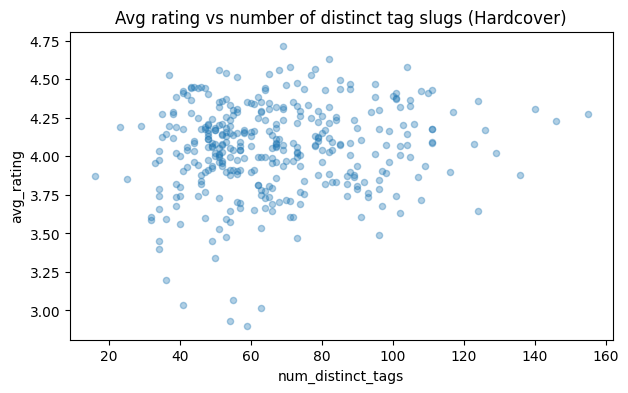

In [ ]:
import importlib.util
import subprocess
import sys

# This operation uses the matplotlib library to create a scatter plot of the above data
# pandas plotting needs matplotlib in this environment
if importlib.util.find_spec("matplotlib") is None:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", "matplotlib"]
    )

ax = df.plot.scatter(x="num_distinct_tags", y="avg_rating", alpha=0.35, figsize=(7, 4))
ax.set_title("Avg rating vs number of distinct tag slugs (Hardcover)");
